In [4]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers,models
from tensorflow.keras.datasets import mnist
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense,Flatten
from tensorflow.keras.utils import to_categorical
from sklearn.metrics import classification_report
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.model_selection import train_test_split

In [5]:
#Load Dataset
(x_train, y_train), (x_test , y_test) = mnist.load_data()

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 4s 0us/step


In [6]:
x_train = x_train.astype('float32') / 255.0
x_test = x_test.astype('float32') / 255.0

y_train = to_categorical(y_train , 10)
y_test = to_categorical(y_test , 10)

In [7]:
#Model Building
model = Sequential()
model.add(layers.Flatten(input_shape = (28, 28)))
model.add(layers.Dense(512 , activation = "relu"))
model.add(layers.Dense(256 , activation = "relu"))
model.add(layers.Dense(128 , activation = "relu"))
model.add(layers.Dense(128 , activation = "relu"))
model.add(layers.Dense(64 , activation = "relu"))
model.add(layers.Dense(32 , activation = "relu"))
model.add(layers.Dense(10 , activation = "softmax"))

c:\Users\naman\AppData\Local\Programs\Python\Python310\lib\site-packages\keras\src\layers\reshaping\flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [8]:
#Model Compiling
model.compile(optimizer = 'adam', loss = "categorical_crossentropy", metrics = ["accuracy"])

history = model.fit(x_train , y_train , epochs = 50 , batch_size = 128 , validation_split = 0.3)

Epoch 1/50
329/329 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.7657 - loss: 0.6997 - val_accuracy: 0.9516 - val_loss: 0.1619
Epoch 2/50
329/329 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.9639 - loss: 0.1226 - val_accuracy: 0.9637 - val_loss: 0.1226
Epoch 3/50
329/329 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.9740 - loss: 0.0853 - val_accuracy: 0.9681 - val_loss: 0.1119
Epoch 4/50
329/329 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.9825 - loss: 0.0579 - val_accuracy: 0.9718 - val_loss: 0.0964
Epoch 5/50
329/329 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.9877 - loss: 0.0391 - val_accuracy: 0.9723 - val_loss: 0.1033
Epoch 6/50
329/329 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.9899 - loss: 0.0328 - val_accuracy: 0.9732 - val_loss: 0.1011
Epoch 7/50
329/329 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.9918 - loss: 0.0255 - val_accuracy: 0.9718 - val_loss: 0.1114
Epoch 8/50
329/329 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.9924 - loss: 0.0237 - val_accuracy: 0.

In [9]:
loss,accuracy = model.evaluate(x_test , y_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9763 - loss: 0.1502


In [10]:
y_pred = model.predict(x_test)
y_pred_classes = tf.argmax(y_pred, axis = 1)
y_true = tf.argmax(y_test , axis = 1)

report = classification_report(y_true , y_pred_classes)
print(report)

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
              precision    recall  f1-score   support

           0       0.98      0.99      0.99       980
           1       0.99      0.99      0.99      1135
           2       0.99      0.97      0.98      1032
           3       0.98      0.97      0.98      1010
           4       0.97      0.99      0.98       982
           5       0.95      0.98      0.97       892
           6       0.99      0.98      0.98       958
           7       0.98      0.98      0.98      1028
           8       0.99      0.95      0.97       974
           9       0.96      0.98      0.97      1009

    accuracy                           0.98     10000
   macro avg       0.98      0.98      0.98     10000
weighted avg       0.98      0.98      0.98     10000



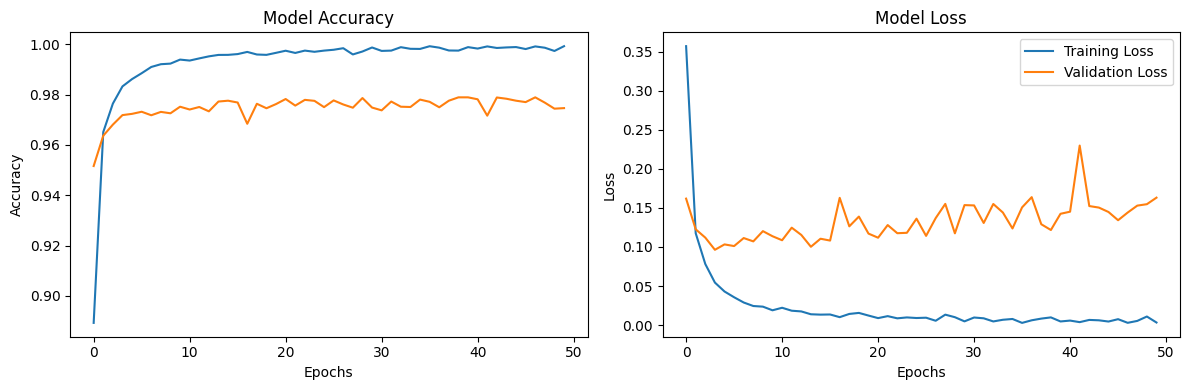

In [11]:
plt.figure(figsize=(12,4))
plt.subplot(1,2,1)
plt.plot(history.history["accuracy"], label="Training Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")
plt.title("Model Accuracy")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()



In [14]:
import tkinter as tk
from tkinter import filedialog
from PIL import Image, ImageTk
import numpy as np
import tensorflow as tf

def open_image():
  file_path = filedialog.askopenfilename()
  if file_path:
          try:
              img = Image.open(file_path).convert('L')
              img_resized = img.resize((28, 28))
              img_array = np.array(img_resized).reshape(1, 28, 28, 1)

              # Debugging statements
              print(f"Image shape after reshape: {img_array.shape}")
              print(f"Image array after reshape and normalize: {img_array}")

              prediction = model.predict(img_array)
              predicted_class = np.argmax(prediction)
              result_label.config(text=f'Predicted Class: {predicted_class}')

              img_display = ImageTk.PhotoImage(img)
              image_label.config(image=img_display)
              image_label.image = img_display

          except Exception as e:
              print(f"Error processing image: {e}")
              result_label.config(text=f"Error: {e}")

root = tk.Tk()
root.title('MNIST Digit Classifier')

open_button = tk.Button(root, text="Open Image", command=open_image)
open_button.pack()

image_label = tk.Label(root)
image_label.pack

result_label = tk.Label(root, text="Prediction will appear here" , font = ("Helvetica", 16))
result_label.pack()

root.mainloop()
        


Image shape after reshape: (1, 28, 28, 1)
Image array after reshape and normalize: [[[[150]
   [150]
   [151]
   [150]
   [154]
   [156]
   [156]
   [157]
   [162]
   [165]
   [164]
   [165]
   [164]
   [173]
   [176]
   [181]
   [182]
   [184]
   [187]
   [186]
   [188]
   [193]
   [197]
   [194]
   [199]
   [200]
   [198]
   [195]]

  [[172]
   [172]
   [174]
   [176]
   [178]
   [181]
   [181]
   [185]
   [187]
   [187]
   [185]
   [187]
   [183]
   [189]
   [196]
   [198]
   [198]
   [198]
   [194]
   [189]
   [200]
   [201]
   [199]
   [188]
   [203]
   [199]
   [192]
   [197]]

  [[171]
   [172]
   [174]
   [177]
   [179]
   [183]
   [185]
   [186]
   [184]
   [186]
   [188]
   [188]
   [186]
   [186]
   [199]
   [198]
   [198]
   [197]
   [193]
   [188]
   [205]
   [204]
   [196]
   [187]
   [199]
   [189]
   [188]
   [197]]

  [[170]
   [172]
   [179]
   [181]
   [180]
   [181]
   [183]
   [185]
   [187]
   [190]
   [191]
   [190]
   [187]
   [185]
   [198]
   [199]
   [199]
  